In [1]:
# ============================================================
# 🎮 Video Game Sales — Unsupervised ML Lab
# Notebook 03 — Clustering & Dimensionality Reduction
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from typing import Literal
import umap

os.environ['OMP_NUM_THREADS'] = '1'

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('../outputs/figures', exist_ok=True)

print('✅ Imports klara')

✅ Imports klara


In [2]:
# ============================================================
# 2. Ladda data
# ============================================================

df: pd.DataFrame = pd.read_csv('../data/vgsales_features.csv')

print(f'Rader:    {len(df):,}')
print(f'Kolumner: {df.shape[1]}')
print()

# Features vi kommer använda
ratio_cols: list[str] = ['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio']
score_cols: list[str] = ['Critic_Score', 'User_Score_scaled']

print('Saknade värden i nyckelkolumner:')
print(df[ratio_cols + score_cols].isnull().sum().to_string())
print()
print(df.head(3).to_string())

Rader:    16,414
Kolumner: 25

Saknade värden i nyckelkolumner:
NA_ratio                0
EU_ratio                0
JP_ratio                0
Other_ratio             0
Critic_Score         8435
User_Score_scaled    8956

                Name Platform  Year_of_Release     Genre Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  Critic_Count  User_Score  User_Count Developer Rating  User_Score_scaled  NA_ratio  EU_ratio  JP_ratio  Other_ratio Platform_Gen  Genre_encoded  Platform_Gen_encoded              Era
0         Wii Sports      Wii             2006    Sports  Nintendo     41.36     28.96      3.77         8.45         82.53          76.0          51.0         8.0       322.0  Nintendo      E               80.0  0.501151  0.350903  0.045680     0.102387      7th-gen             10                     2  7th gen (03–10)
1  Super Mario Bros.      NES             1985  Platform  Nintendo     29.08      3.58      6.81         0.77         40.24           N

In [3]:
# ============================================================
# 3. Förbered data för klustring
# ============================================================

# Experiment 1 — regional ratios (inga nulls, alla 16 414 spel)
X_ratios: np.ndarray = np.asarray(df[ratio_cols].values)

scaler: StandardScaler = StandardScaler()
X_ratios_scaled: np.ndarray = np.asarray(scaler.fit_transform(X_ratios))

print(f'Experiment 1 — Regional ratios')
print(f'  Rader:    {X_ratios_scaled.shape[0]:,}')
print(f'  Features: {X_ratios_scaled.shape[1]}')
print(f'  Features: {ratio_cols}')
print()

# Kontroll — medelvärde ska vara ~0, std ~1 efter scaling
means: np.ndarray = np.asarray(X_ratios_scaled.mean(axis=0).round(3))
stds: np.ndarray  = np.asarray(X_ratios_scaled.std(axis=0).round(3))
print(f'  Medelvärde per feature: {means}')
print(f'  Std per feature:        {stds}')

Experiment 1 — Regional ratios
  Rader:    16,414
  Features: 4
  Features: ['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio']

  Medelvärde per feature: [ 0. -0.  0. -0.]
  Std per feature:        [1. 1. 1. 1.]


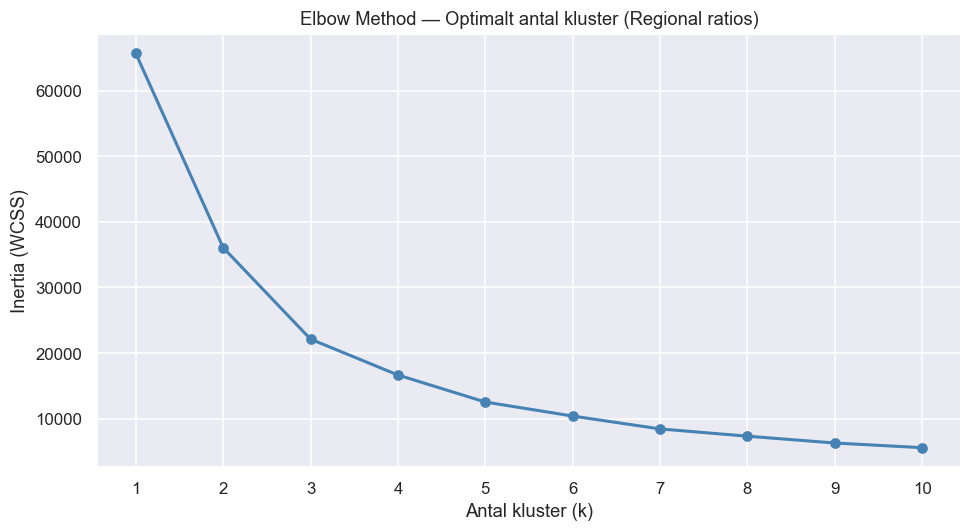

WCSS per k:
  k=1: 65656.0
  k=2: 36070.7
  k=3: 22131.5
  k=4: 16668.2
  k=5: 12549.8
  k=6: 10413.8
  k=7: 8454.6
  k=8: 7344.3
  k=9: 6306.0
  k=10: 5596.5


In [4]:
# ============================================================
# 4. Experiment 1 — Elbow Method (WCSS)
# ============================================================

wcss: list[float] = []
k_range: range = range(1, 11)

for k in k_range:
    km: KMeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_ratios_scaled)
    wcss.append(float(km.inertia_))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), wcss, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — Optimalt antal kluster (Regional ratios)')
ax.set_xlabel('Antal kluster (k)')
ax.set_ylabel('Inertia (WCSS)')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('../outputs/figures/03_elbow.png', bbox_inches='tight', dpi=150)
plt.show()

print('WCSS per k:')
for k, w in zip(k_range, wcss):
    print(f'  k={k}: {w:.1f}')

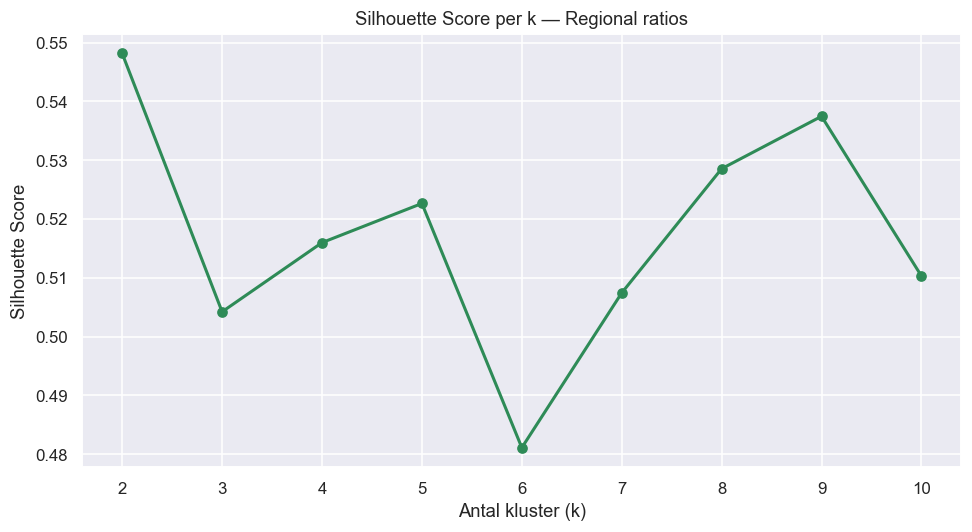

Bästa k enligt Silhouette: 2 (score: 0.548)


In [5]:
# ============================================================
# 5. Experiment 1 — Silhouette Score per k
# ============================================================

silhouette_scores: list[float] = []
k_range_sil: range = range(2, 11)

for k in k_range_sil:
    km: KMeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels: np.ndarray = np.asarray(km.fit_predict(X_ratios_scaled))
    score: float = float(silhouette_score(X_ratios_scaled, labels))
    silhouette_scores.append(score)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range_sil), silhouette_scores, marker='o', color='seagreen', linewidth=2)
ax.set_title('Silhouette Score per k — Regional ratios')
ax.set_xlabel('Antal kluster (k)')
ax.set_ylabel('Silhouette Score')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('../outputs/figures/04_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

best_k: int = int(k_range_sil.start + silhouette_scores.index(max(silhouette_scores)))
print(f'Bästa k enligt Silhouette: {best_k} (score: {max(silhouette_scores):.3f})')

In [6]:
# ============================================================
# 6. Experiment 1 — K-Means k=2 vs k=4
# ============================================================

results: dict[int, dict] = {}

for k in [2, 4]:
    km: KMeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels: np.ndarray = np.asarray(km.fit_predict(X_ratios_scaled))
    centroids: np.ndarray = np.asarray(scaler.inverse_transform(km.cluster_centers_))
    
    results[k] = {
        'model':     km,
        'labels':    labels,
        'centroids': centroids,
        'silhouette': float(silhouette_score(X_ratios_scaled, labels))
    }

# Spara k=4 labels till df för senare analys
df['Cluster_k4'] = results[4]['labels']
df['Cluster_k2'] = results[2]['labels']

# Jämförelsetabell — centroider
for k in [2, 4]:
    print(f'--- k={k}  |  Silhouette: {results[k]["silhouette"]:.3f} ---')
    cdf: pd.DataFrame = pd.DataFrame(results[k]['centroids'], columns=ratio_cols)
    cdf.index.name = 'Kluster'
    print(cdf.round(3).to_string())
    print()

--- k=2  |  Silhouette: 0.548 ---
         NA_ratio  EU_ratio  JP_ratio  Other_ratio
Kluster                                           
0           0.024     0.012     0.955        0.009
1           0.587     0.293     0.030        0.080

--- k=4  |  Silhouette: 0.516 ---
         NA_ratio  EU_ratio  JP_ratio  Other_ratio
Kluster                                           
0           0.022     0.011     0.957        0.008
1           0.794     0.120     0.025        0.042
2           0.464     0.369     0.043        0.128
3           0.046     0.843     0.008        0.075



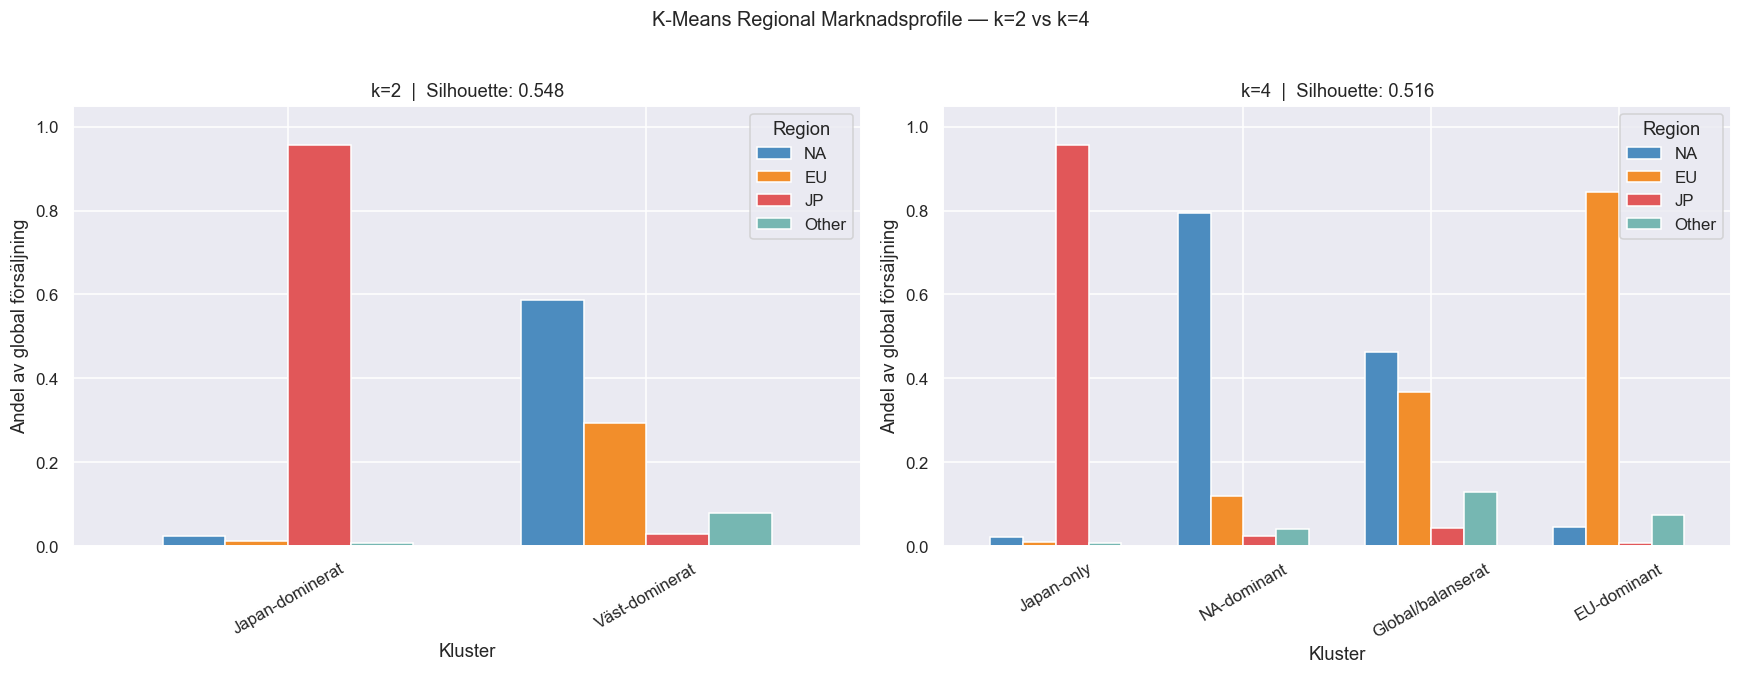

k=2: Bekräftar JP vs Väst som dominant axel
k=4: Avslöjar NA-dominant, EU-dominant och Global som separata segment


In [7]:
# ============================================================
# 7. Experiment 1 — Visualisering k=2 vs k=4
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_names_k2: dict[int, str] = {
    0: 'Japan-dominerat',
    1: 'Väst-dominerat'
}

cluster_names_k4: dict[int, str] = {
    0: 'Japan-only',
    1: 'NA-dominant',
    2: 'Global/balanserat',
    3: 'EU-dominant'
}

colors_k2: list[str] = ['#e15759', '#4c8cbf']
colors_k4: list[str] = ['#e15759', '#4c8cbf', '#59a14f', '#f28e2b']

for ax, k, names, colors in zip(
    axes,
    [2, 4],
    [cluster_names_k2, cluster_names_k4],
    [colors_k2, colors_k4]
):
    cdf: pd.DataFrame = pd.DataFrame(
        results[k]['centroids'],
        columns=['NA', 'EU', 'JP', 'Other']
    )
    cdf.index = [names[i] for i in range(k)]

    cdf.plot(
        kind='bar',
        ax=ax,
        color=['#4c8cbf', '#f28e2b', '#e15759', '#76b7b2'],
        edgecolor='white',
        width=0.7
    )

    sil: float = results[k]['silhouette']
    ax.set_title(f'k={k}  |  Silhouette: {sil:.3f}')
    ax.set_xlabel('Kluster')
    ax.set_ylabel('Andel av global försäljning')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['NA', 'EU', 'JP', 'Other'], title='Region')

plt.suptitle('K-Means Regional Marknadsprofile — k=2 vs k=4', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/05_kmeans_k2_k4.png', bbox_inches='tight', dpi=150)
plt.show()

print('k=2: Bekräftar JP vs Väst som dominant axel')
print('k=4: Avslöjar NA-dominant, EU-dominant och Global som separata segment')

In [8]:
# ============================================================
# 8. Experiment 1 — Klusteranalys k=4
# ============================================================

cluster_names: dict[int, str] = {
    0: 'Japan-only',
    1: 'NA-dominant',
    2: 'Global/balanserat',
    3: 'EU-dominant'
}

df['Cluster_k4_name'] = df['Cluster_k4'].map(cluster_names)

print('=== Klusterstorlek ===')
print(df['Cluster_k4_name'].value_counts().to_string())
print()

print('=== Top 3 Genre per kluster ===')
for c in range(4):
    mask: pd.Series = df['Cluster_k4'] == c
    top_genres: pd.Series = df.loc[mask, 'Genre'].value_counts().head(3)
    print(f'\n{cluster_names[c]}:')
    print(top_genres.to_string())

print()
print('=== Top 5 spel per kluster (Global Sales) ===')
for c in range(4):
    mask = df['Cluster_k4'] == c
    top_games: pd.DataFrame = (
        df.loc[mask, ['Name', 'Genre', 'Global_Sales']]
        .sort_values('Global_Sales', ascending=False)
        .head(5)
    )
    print(f'\n{cluster_names[c]}:')
    print(top_games.to_string(index=False))

=== Klusterstorlek ===
Cluster_k4_name
NA-dominant          6313
Global/balanserat    5003
Japan-only           3800
EU-dominant          1298

=== Top 3 Genre per kluster ===

Japan-only:
Genre
Role-Playing    679
Adventure       670
Action          637

NA-dominant:
Genre
Action    1190
Sports    1084
Misc       739

Global/balanserat:
Genre
Action     1269
Sports      642
Shooter     583

EU-dominant:
Genre
Action      211
Sports      206
Strategy    153

=== Top 5 spel per kluster (Global Sales) ===

Japan-only:
                                          Name        Genre  Global_Sales
                     Animal Crossing: New Leaf   Simulation          9.16
                            Final Fantasy VIII Role-Playing          7.86
Dragon Quest IX: Sentinels of the Starry Skies Role-Playing          5.78
                  Monster Hunter Freedom Unite Role-Playing          5.48
                              Final Fantasy IX Role-Playing          5.30

NA-dominant:
              Name  

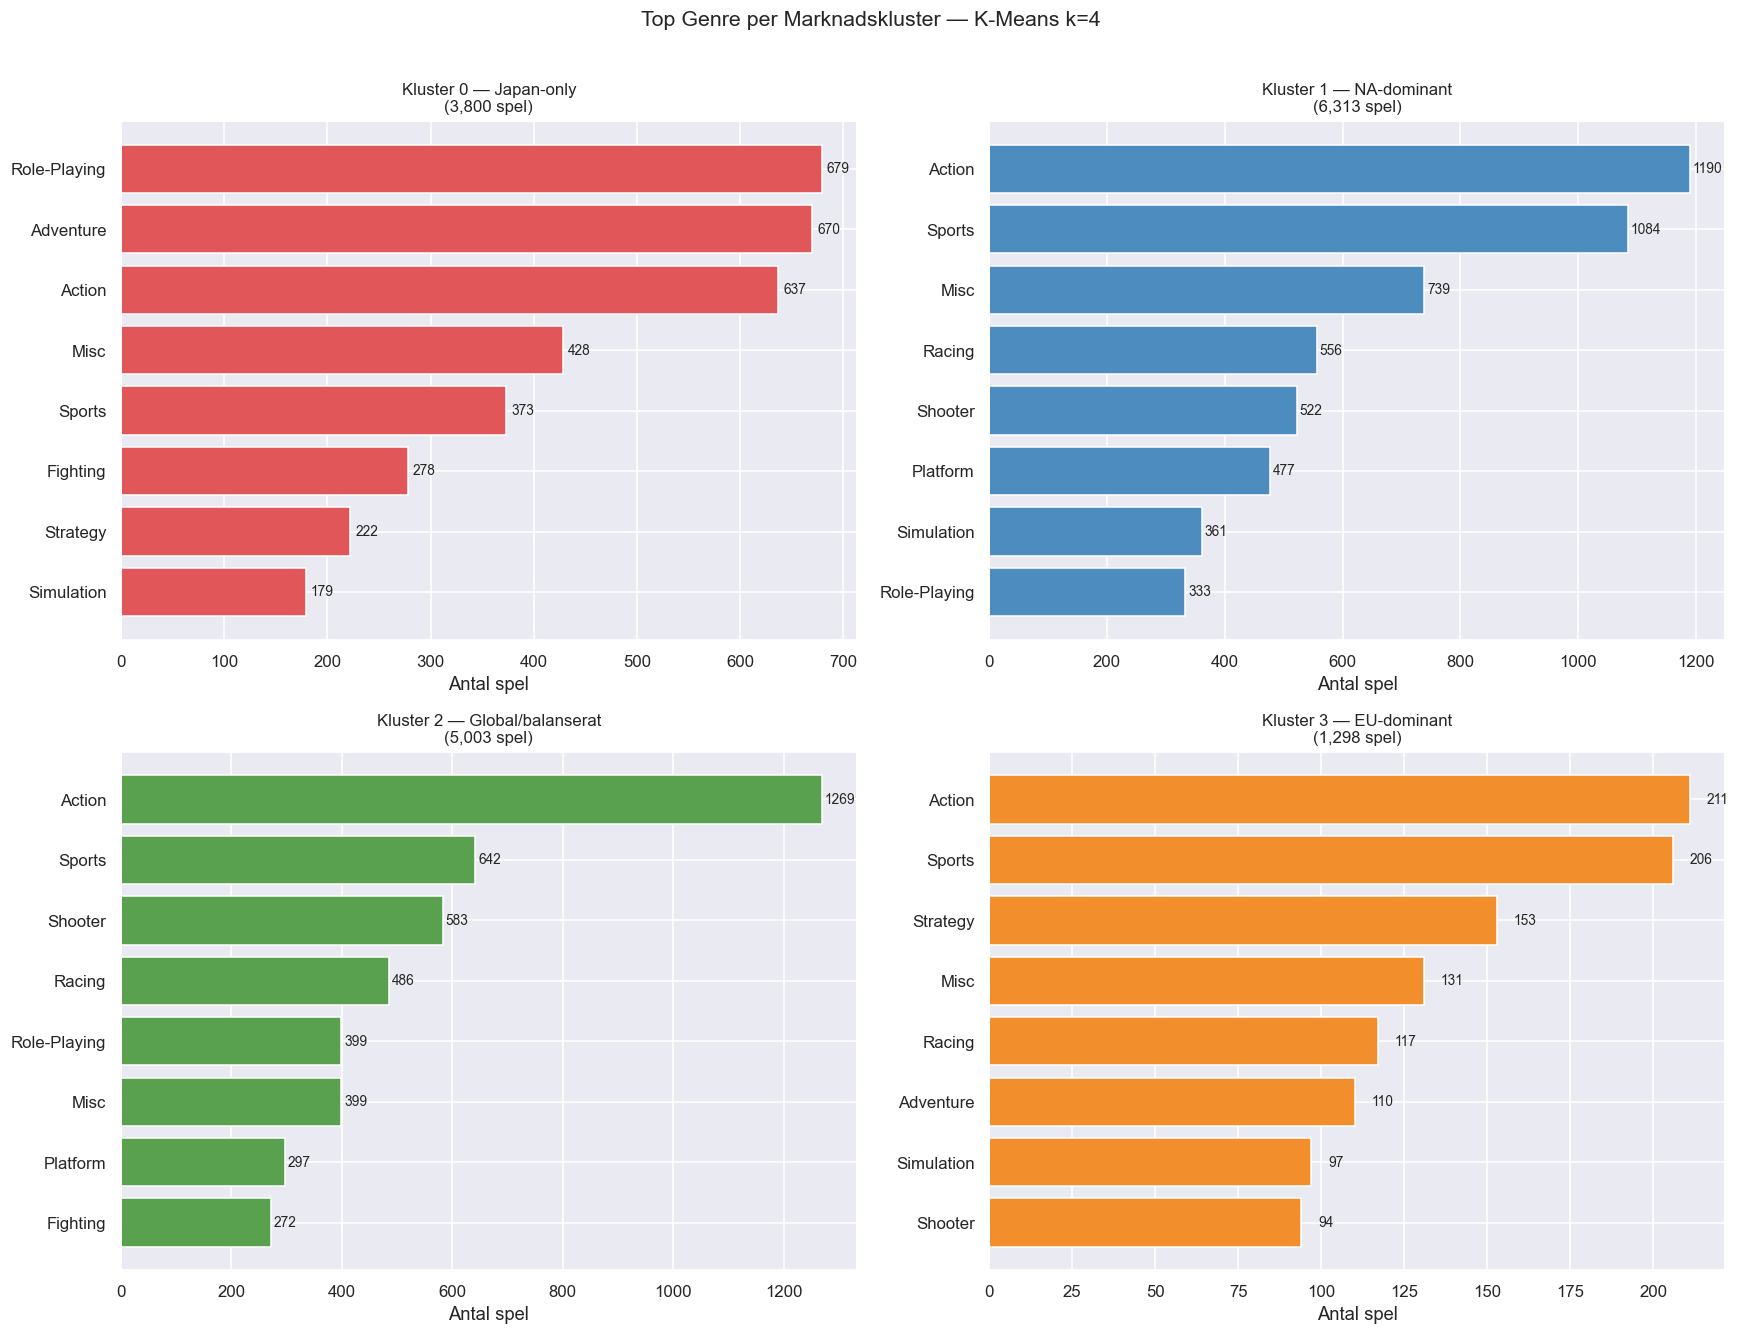

In [9]:
# ============================================================
# 9. Experiment 1 — Genre per kluster (visualisering)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for c in range(4):
    mask: pd.Series = df['Cluster_k4'] == c
    genre_counts: pd.Series = (
        df.loc[mask, 'Genre']
        .value_counts()
        .head(8)
    )
    
    ax = axes_flat[c]
    bars = ax.barh(
        genre_counts.index[::-1],
        genre_counts.values[::-1],
        color=colors_k4[c],
        edgecolor='white'
    )
    
    ax.set_title(f'Kluster {c} — {cluster_names[c]}\n'
                 f'({int(mask.sum()):,} spel)', fontsize=11)
    ax.set_xlabel('Antal spel')
    
    for bar, val in zip(bars, genre_counts.values[::-1]):
        ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)

plt.suptitle('Top Genre per Marknadskluster — K-Means k=4', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/06_genre_per_cluster.png', bbox_inches='tight', dpi=150)
plt.show()

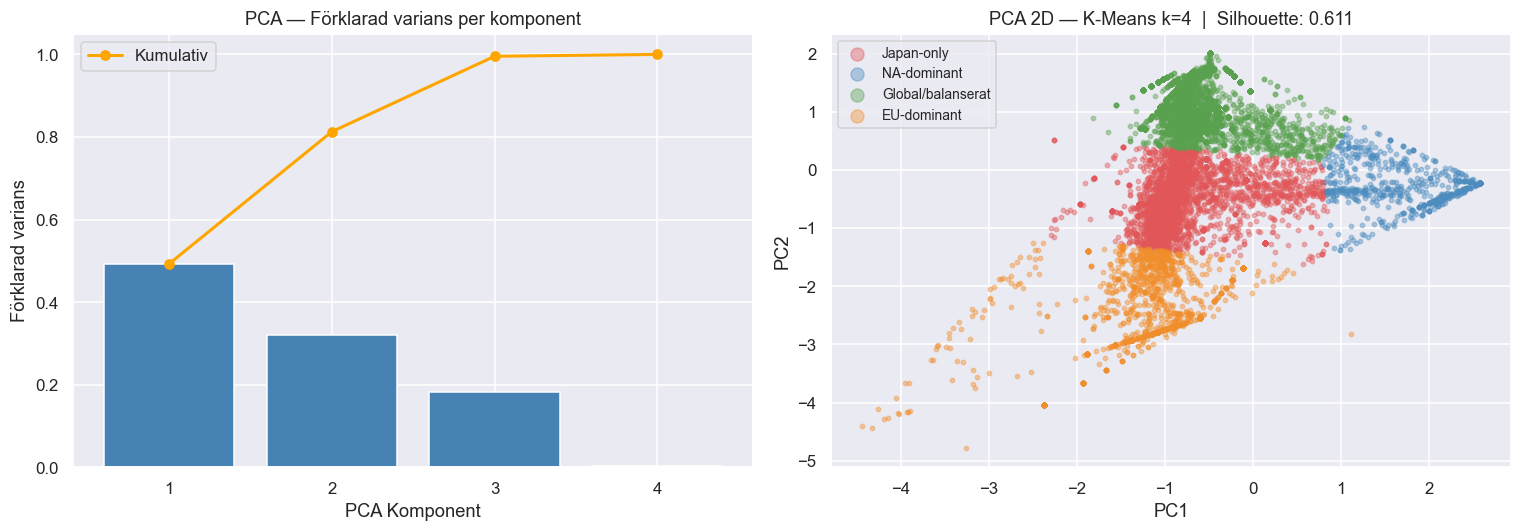

Förklarad varians per komponent:
  PC1: 0.493  (kumulativ: 0.493)
  PC2: 0.320  (kumulativ: 0.813)
  PC3: 0.183  (kumulativ: 0.996)
  PC4: 0.004  (kumulativ: 1.000)

Silhouette PCA 2D: 0.611
Silhouette raw K-Means k=4: 0.516


In [10]:
# ============================================================
# 10. PCA — Dimensionsreduktion + K-Means
# ============================================================

pca: PCA = PCA(n_components=4, random_state=42)
X_pca_full: np.ndarray = np.asarray(pca.fit_transform(X_ratios_scaled))

# Förklarad varians
explained: np.ndarray = np.asarray(pca.explained_variance_ratio_)
cumulative: np.ndarray = np.asarray(np.cumsum(explained))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 5), explained, color='steelblue', edgecolor='white')
axes[0].plot(range(1, 5), cumulative, marker='o', color='orange', linewidth=2, label='Kumulativ')
axes[0].set_title('PCA — Förklarad varians per komponent')
axes[0].set_xlabel('PCA Komponent')
axes[0].set_ylabel('Förklarad varians')
axes[0].set_xticks(range(1, 5))
axes[0].legend()

# 2D scatter — PC1 vs PC2, färgad av k=4 kluster
X_pca_2d: np.ndarray = X_pca_full[:, :2]
km_pca: KMeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
pca_labels: np.ndarray = np.asarray(km_pca.fit_predict(X_pca_2d))
sil_pca: float = float(silhouette_score(X_pca_2d, pca_labels))

for c in range(4):
    mask: np.ndarray = pca_labels == c
    axes[1].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        s=8, alpha=0.4, color=colors_k4[c],
        label=cluster_names[c]
    )

axes[1].set_title(f'PCA 2D — K-Means k=4  |  Silhouette: {sil_pca:.3f}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/07_pca_2d.png', bbox_inches='tight', dpi=150)
plt.show()

print('Förklarad varians per komponent:')
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f'  PC{i+1}: {ev:.3f}  (kumulativ: {cv:.3f})')
print(f'\nSilhouette PCA 2D: {sil_pca:.3f}')
print(f'Silhouette raw K-Means k=4: {results[4]["silhouette"]:.3f}')

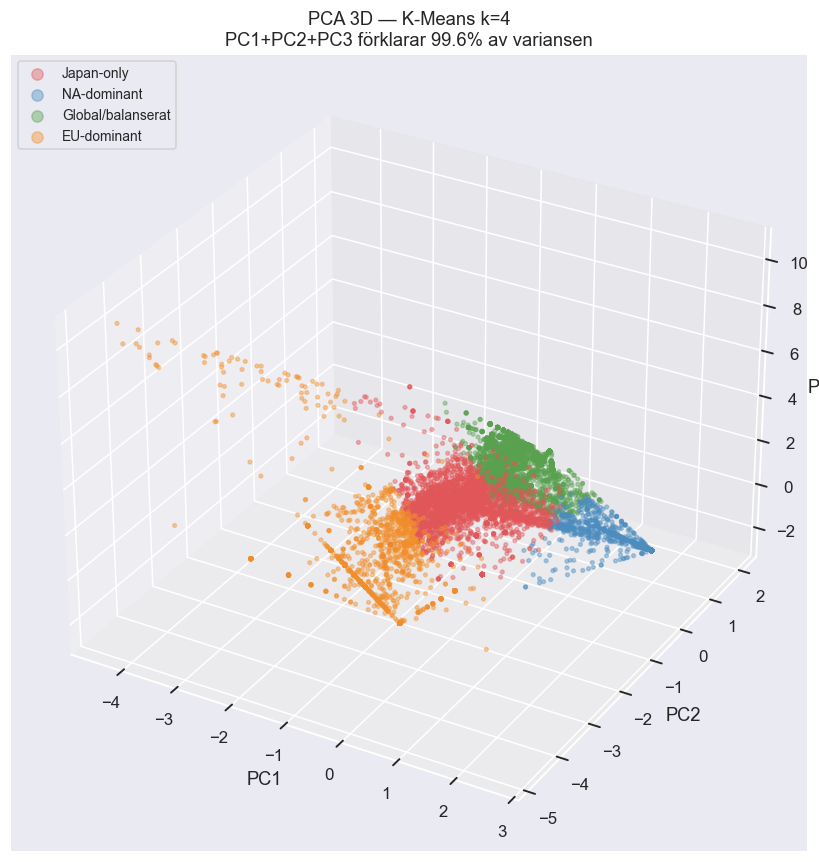

PC1+PC2+PC3: 99.6% förklarad varians


In [11]:
# ============================================================
# 11. PCA 3D — PC1 vs PC2 vs PC3
# ============================================================

X_pca_3d: np.ndarray = X_pca_full[:, :3]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for c in range(4):
    mask: np.ndarray = pca_labels == c
    ax.scatter(
        X_pca_3d[mask, 0],
        X_pca_3d[mask, 1],
        X_pca_3d[mask, 2],
        s=6, alpha=0.4,
        color=colors_k4[c],
        label=cluster_names[c]
    )

ax.set_title('PCA 3D — K-Means k=4\n'
             f'PC1+PC2+PC3 förklarar {cumulative[2]:.1%} av variansen')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(markerscale=3, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/figures/08_pca_3d.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'PC1+PC2+PC3: {cumulative[2]:.1%} förklarad varians')

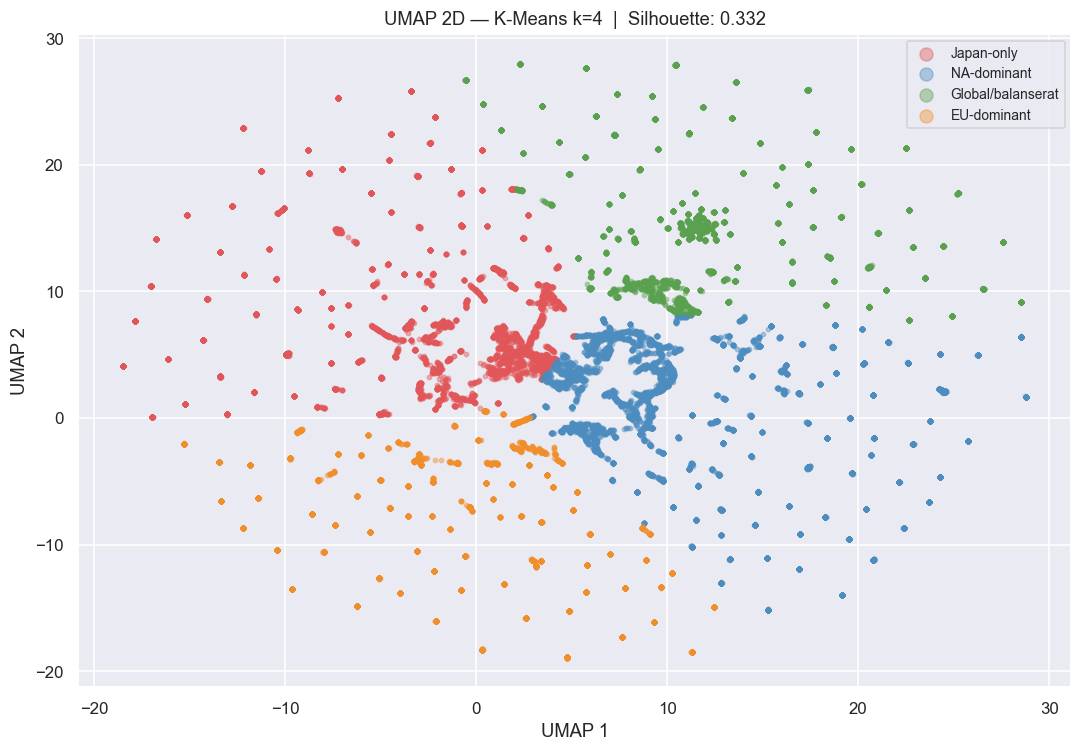

Silhouette raw K-Means:    0.516
Silhouette PCA + K-Means:  0.611
Silhouette UMAP + K-Means: 0.332


In [12]:
# ============================================================
# 12. UMAP 2D — K-Means
# ============================================================

np.random.seed(42)

reducer_2d: umap.UMAP = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    init='random'
)

X_umap_2d: np.ndarray = np.asarray(reducer_2d.fit_transform(X_ratios_scaled))

km_umap: KMeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
umap_labels: np.ndarray = np.asarray(km_umap.fit_predict(X_umap_2d))
sil_umap_2d: float = float(silhouette_score(X_umap_2d, umap_labels))

fig, ax = plt.subplots(figsize=(10, 7))

for c in range(4):
    mask: np.ndarray = umap_labels == c
    ax.scatter(
        X_umap_2d[mask, 0],
        X_umap_2d[mask, 1],
        s=8, alpha=0.4,
        color=colors_k4[c],
        label=cluster_names[c]
    )

ax.set_title(f'UMAP 2D — K-Means k=4  |  Silhouette: {sil_umap_2d:.3f}')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/09_umap_2d.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Silhouette raw K-Means:    {results[4]["silhouette"]:.3f}')
print(f'Silhouette PCA + K-Means:  {sil_pca:.3f}')
print(f'Silhouette UMAP + K-Means: {sil_umap_2d:.3f}')

In [13]:
# ============================================================
# 12b. UMAP — testa n_neighbors
# ============================================================

np.random.seed(42)

for n in [5, 30, 50]:
    r: umap.UMAP = umap.UMAP(
        n_components=2,
        n_neighbors=n,
        min_dist=0.1,
        metric='euclidean',
        init='random'
    )
    emb: np.ndarray = np.asarray(r.fit_transform(X_ratios_scaled))
    labels_tmp: np.ndarray = np.asarray(
        KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
        .fit_predict(emb)
    )
    sil: float = float(silhouette_score(emb, labels_tmp))
    print(f'n_neighbors={n:>2}: Silhouette={sil:.3f}')

n_neighbors= 5: Silhouette=0.325
n_neighbors=30: Silhouette=0.367
n_neighbors=50: Silhouette=0.395


In [14]:
# ============================================================
# 12c. UMAP — utökad n_neighbors sökning
# ============================================================

np.random.seed(42)

for n in [75, 100, 150, 200]:
    r: umap.UMAP = umap.UMAP(
        n_components=2,
        n_neighbors=n,
        min_dist=0.1,
        metric='euclidean',
        init='random'
    )
    emb: np.ndarray = np.asarray(r.fit_transform(X_ratios_scaled))
    labels_tmp: np.ndarray = np.asarray(
        KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
        .fit_predict(emb)
    )
    sil: float = float(silhouette_score(emb, labels_tmp))
    print(f'n_neighbors={n:>3}: Silhouette={sil:.3f}')

n_neighbors= 75: Silhouette=0.448
n_neighbors=100: Silhouette=0.502
n_neighbors=150: Silhouette=0.529
n_neighbors=200: Silhouette=0.559


In [15]:
# ============================================================
# 12d. UMAP — sista sökning
# ============================================================

np.random.seed(42)

for n in [300, 500, 750]:
    r: umap.UMAP = umap.UMAP(
        n_components=2,
        n_neighbors=n,
        min_dist=0.1,
        metric='euclidean',
        init='random'
    )
    emb: np.ndarray = np.asarray(r.fit_transform(X_ratios_scaled))
    labels_tmp: np.ndarray = np.asarray(
        KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
        .fit_predict(emb)
    )
    sil: float = float(silhouette_score(emb, labels_tmp))
    print(f'n_neighbors={n:>3}: Silhouette={sil:.3f}')

n_neighbors=300: Silhouette=0.599
n_neighbors=500: Silhouette=0.597
n_neighbors=750: Silhouette=0.618


In [17]:
# ============================================================
# 12e. UMAP — final sökning
# ============================================================

np.random.seed(42)

for n in [1000, 2000]:
    r: umap.UMAP = umap.UMAP(
        n_components=2,
        n_neighbors=n,
        min_dist=0.1,
        metric='euclidean',
        init='random'
    )
    emb: np.ndarray = np.asarray(r.fit_transform(X_ratios_scaled))
    labels_tmp: np.ndarray = np.asarray(
        KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
        .fit_predict(emb)
    )
    sil: float = float(silhouette_score(emb, labels_tmp))
    print(f'n_neighbors={n:>4}: Silhouette={sil:.3f}')

KeyboardInterrupt: 

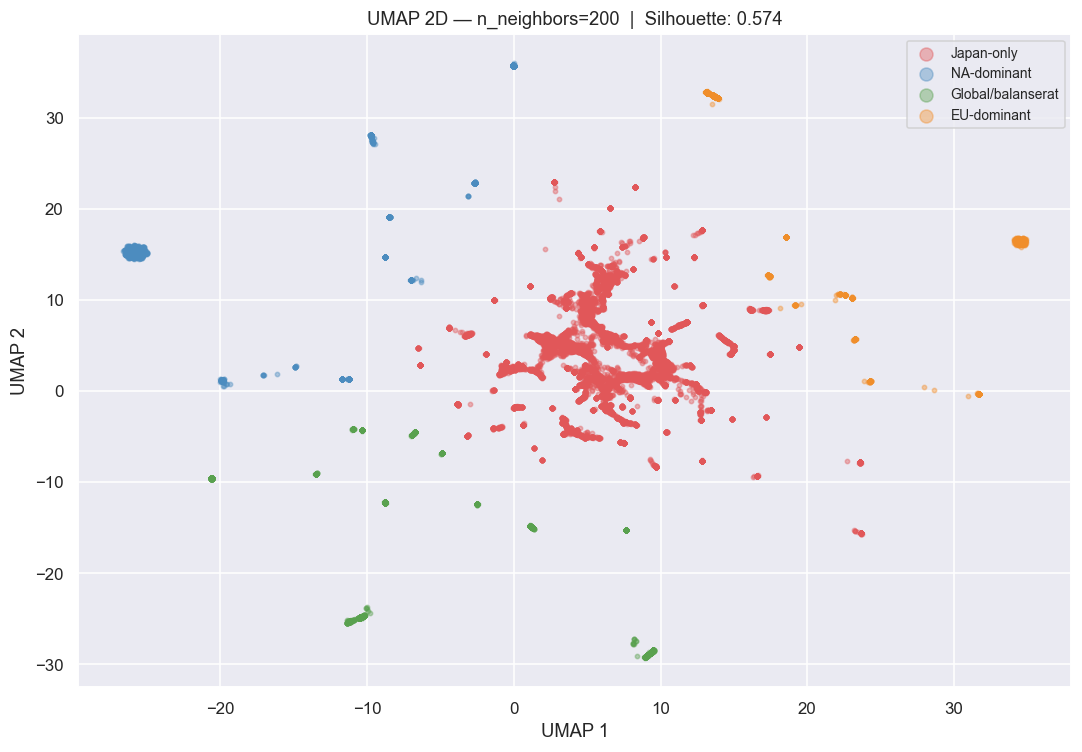

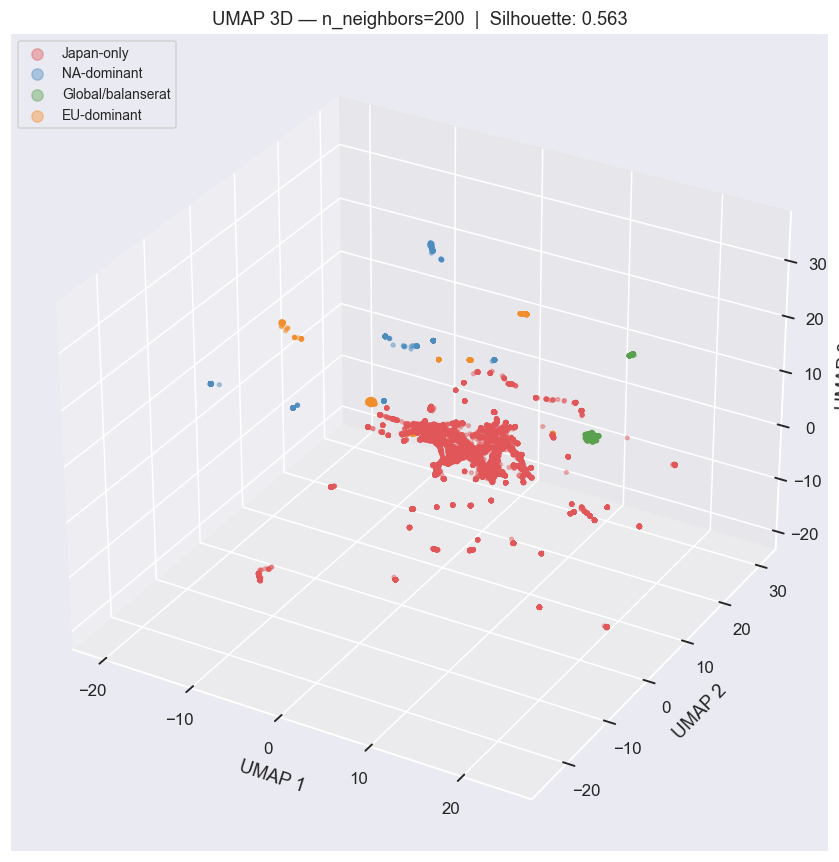

Silhouette raw K-Means:    0.516
Silhouette PCA + K-Means:  0.611
Silhouette UMAP + K-Means: 0.574

Slutsats: PCA är överlägset för detta dataset — variansen är linjär (99.6% i 3 komponenter)


In [ ]:
# ============================================================
# 13. UMAP Final — 2D + 3D (n_neighbors=200)
# ============================================================

np.random.seed(42)

# 2D
reducer_final_2d: umap.UMAP = umap.UMAP(
    n_components=2, n_neighbors=200,
    min_dist=0.1, metric='euclidean', init='random'
)
X_umap_final_2d: np.ndarray = np.asarray(reducer_final_2d.fit_transform(X_ratios_scaled))

km_umap_final: KMeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
umap_final_labels: np.ndarray = np.asarray(km_umap_final.fit_predict(X_umap_final_2d))
sil_umap_final: float = float(silhouette_score(X_umap_final_2d, umap_final_labels))

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(4):
    mask: np.ndarray = umap_final_labels == c
    ax.scatter(
        X_umap_final_2d[mask, 0], X_umap_final_2d[mask, 1],
        s=8, alpha=0.4, color=colors_k4[c], label=cluster_names[c]
    )
ax.set_title(f'UMAP 2D — n_neighbors=200  |  Silhouette: {sil_umap_final:.3f}')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/10_umap_2d_final.png', bbox_inches='tight', dpi=150)
plt.show()

# 3D
np.random.seed(42)
reducer_final_3d: umap.UMAP = umap.UMAP(
    n_components=3, n_neighbors=200,
    min_dist=0.1, metric='euclidean', init='random'
)
X_umap_final_3d: np.ndarray = np.asarray(reducer_final_3d.fit_transform(X_ratios_scaled))

km_umap_3d: KMeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
umap_3d_labels: np.ndarray = np.asarray(km_umap_3d.fit_predict(X_umap_final_3d))
sil_umap_3d: float = float(silhouette_score(X_umap_final_3d, umap_3d_labels))

fig = plt.figure(figsize=(12, 8))
ax3d = fig.add_subplot(111, projection='3d')
for c in range(4):
    mask = umap_3d_labels == c
    ax3d.scatter(
        X_umap_final_3d[mask, 0], X_umap_final_3d[mask, 1], X_umap_final_3d[mask, 2],
        s=6, alpha=0.4, color=colors_k4[c], label=cluster_names[c]
    )
ax3d.set_title(f'UMAP 3D — n_neighbors=200  |  Silhouette: {sil_umap_3d:.3f}')
ax3d.set_xlabel('UMAP 1')
ax3d.set_ylabel('UMAP 2')
ax3d.set_zlabel('UMAP 3')
ax3d.legend(markerscale=3, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/figures/11_umap_3d_final.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Silhouette raw K-Means:    {results[4]["silhouette"]:.3f}')
print(f'Silhouette PCA + K-Means:  {sil_pca:.3f}')
print(f'Silhouette UMAP + K-Means: {sil_umap_final:.3f}')
print()
print('Slutsats: PCA är överlägset för detta dataset — variansen är linjär (99.6% i 3 komponenter)')

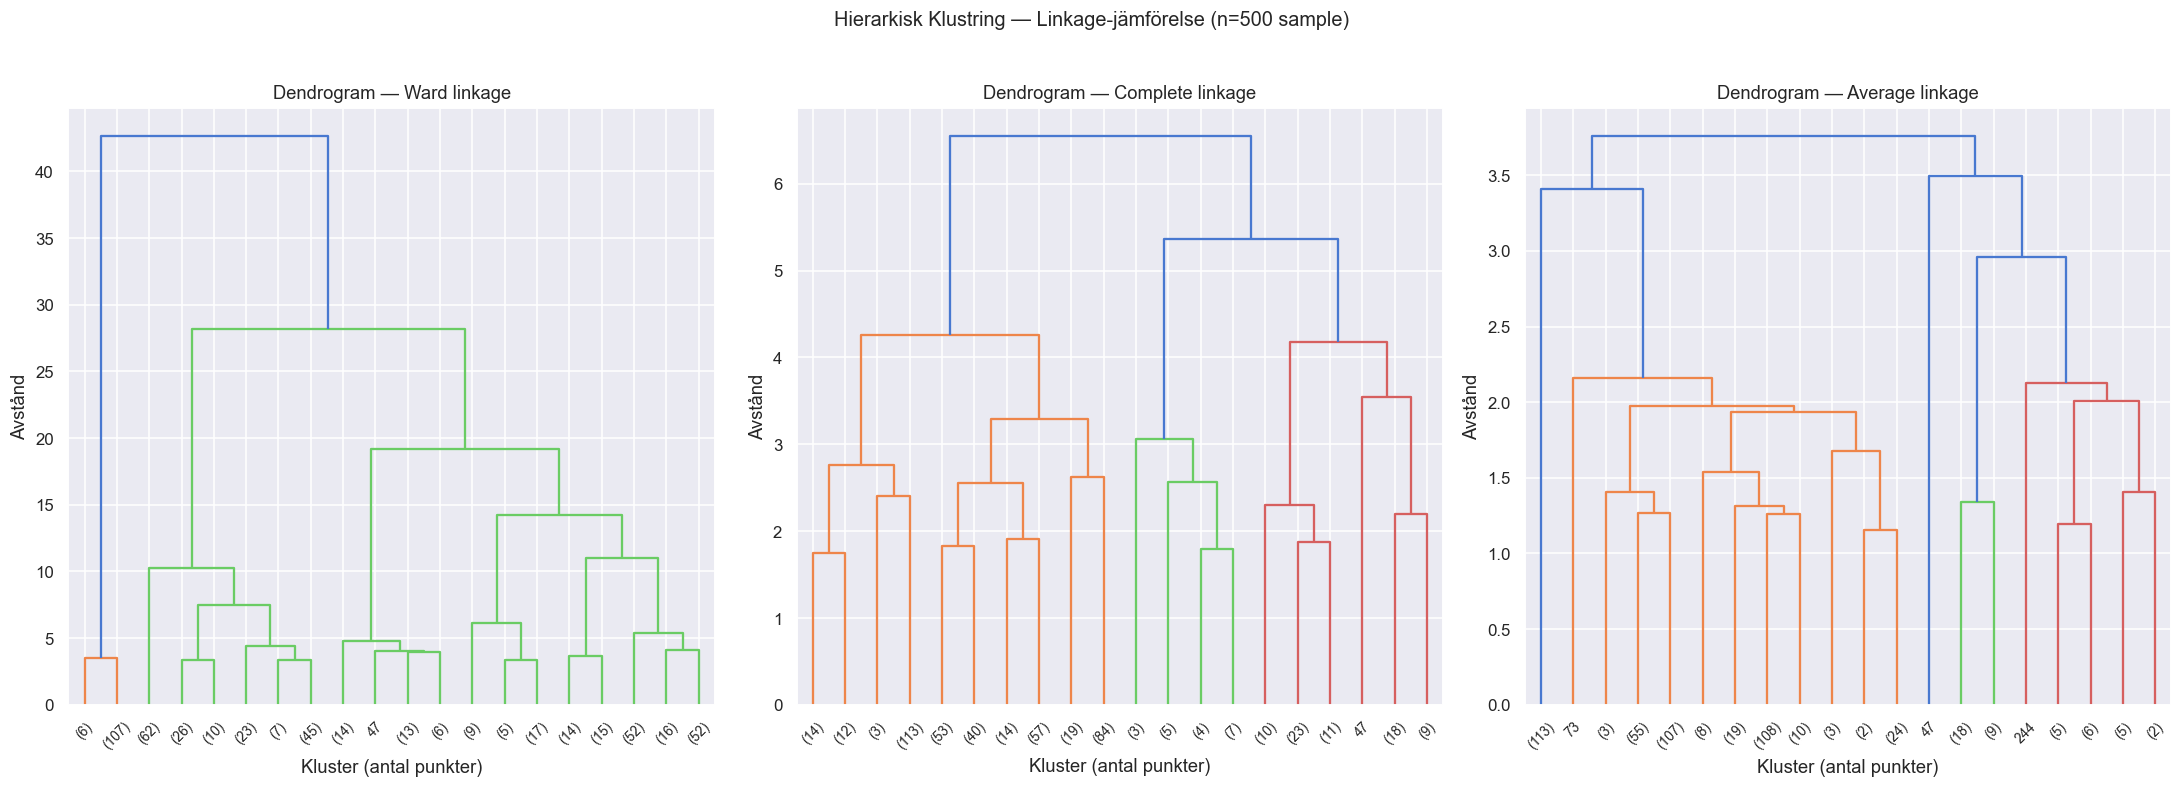

In [ ]:
# ============================================================
# 14. Hierarkisk Klustring — Dendrogram
# ============================================================

# Använd ett sample — hierarkisk klustring är O(n²) i minne
np.random.seed(42)
sample_idx: np.ndarray = np.random.choice(len(X_ratios_scaled), 500, replace=False)
X_sample: np.ndarray = X_ratios_scaled[sample_idx]
sample_names: np.ndarray = np.asarray(df['Genre'].values[sample_idx])

# Jämför tre linkage-metoder
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, method in zip(axes, ['ward', 'complete', 'average']):
    Z: np.ndarray = np.asarray(linkage(X_sample, method=method))
    dendrogram(
        Z, ax=ax,
        truncate_mode='lastp',
        p=20,
        leaf_rotation=45,
        leaf_font_size=9,
        color_threshold=0.7 * max(Z[:, 2])
    )
    ax.set_title(f'Dendrogram — {method.capitalize()} linkage')
    ax.set_xlabel('Kluster (antal punkter)')
    ax.set_ylabel('Avstånd')

plt.suptitle('Hierarkisk Klustring — Linkage-jämförelse (n=500 sample)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/12_dendrogram.png', bbox_inches='tight', dpi=150)
plt.show()

Silhouette per linkage-metod (sample n=500):
        ward: 0.509
    complete: 0.482
     average: 0.557

Bästa metod: average (0.557)


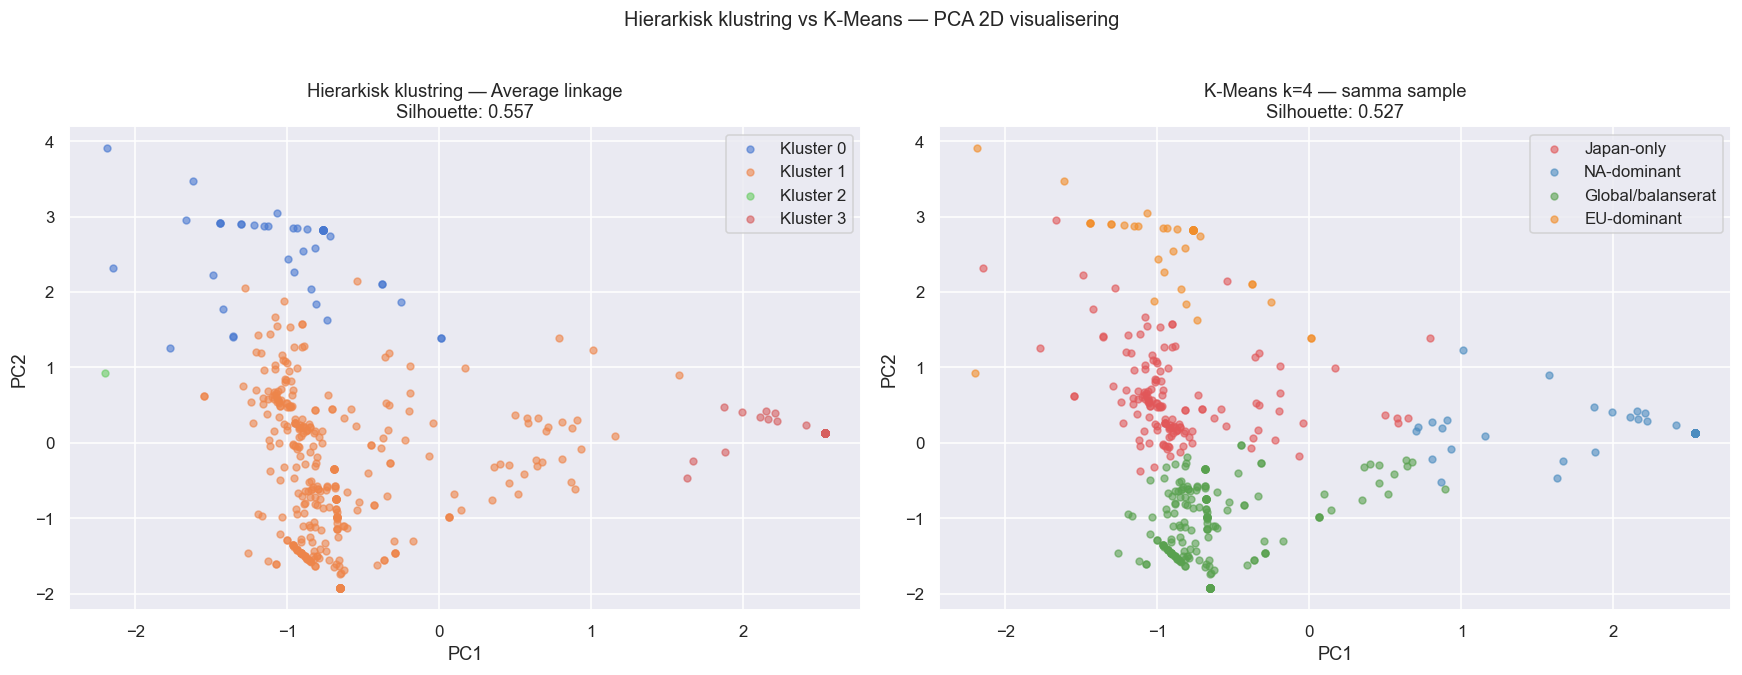


=== Slutlig Silhouette-jämförelse ===
  K-Means (full dataset):      0.516
  PCA + K-Means:               0.611
  UMAP + K-Means (n=200):      0.574
  Hierarkisk (average): 0.557


In [ ]:
# ============================================================
# 15. Hierarkisk Klustring — AgglomerativeClustering k=4
# ============================================================
from typing import Literal

LinkageMethod = Literal['ward', 'complete', 'average', 'single']

linkage_methods: list[LinkageMethod] = ['ward', 'complete', 'average']
sil_scores: dict[str, float] = {}

for method in linkage_methods:
    agg: AgglomerativeClustering = AgglomerativeClustering(
        n_clusters=4, linkage=method
    )
    agg_labels: np.ndarray = np.asarray(agg.fit_predict(X_sample))
    sil_scores[method] = float(silhouette_score(X_sample, agg_labels))

print('Silhouette per linkage-metod (sample n=500):')
for method, sil in sil_scores.items():
    print(f'  {method:>10}: {sil:.3f}')

best_method: LinkageMethod = max(sil_scores, key=lambda m: sil_scores[m])  # type: ignore[assignment]
print(f'\nBästa metod: {best_method} ({sil_scores[best_method]:.3f})')

# Träna bästa modellen och visualisera
agg_best: AgglomerativeClustering = AgglomerativeClustering(
    n_clusters=4, linkage=best_method
)
agg_best_labels: np.ndarray = np.asarray(agg_best.fit_predict(X_sample))

# PCA 2D för visualisering av hierarkiska kluster
pca_vis: PCA = PCA(n_components=2, random_state=42)
X_sample_pca: np.ndarray = np.asarray(pca_vis.fit_transform(X_sample))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hierarkisk klustring
for c in range(4):
    mask: np.ndarray = agg_best_labels == c
    axes[0].scatter(
        X_sample_pca[mask, 0], X_sample_pca[mask, 1],
        s=20, alpha=0.6, label=f'Kluster {c}'
    )
axes[0].set_title(f'Hierarkisk klustring — {best_method.capitalize()} linkage\n'
                  f'Silhouette: {sil_scores[best_method]:.3f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# K-Means på samma sample för direkt jämförelse
km_sample: KMeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
km_sample_labels: np.ndarray = np.asarray(km_sample.fit_predict(X_sample))
sil_km_sample: float = float(silhouette_score(X_sample, km_sample_labels))

for c in range(4):
    mask = km_sample_labels == c
    axes[1].scatter(
        X_sample_pca[mask, 0], X_sample_pca[mask, 1],
        s=20, alpha=0.6, color=colors_k4[c], label=cluster_names[c]
    )
axes[1].set_title(f'K-Means k=4 — samma sample\n'
                  f'Silhouette: {sil_km_sample:.3f}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('Hierarkisk klustring vs K-Means — PCA 2D visualisering', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/13_hierarchical_vs_kmeans.png', bbox_inches='tight', dpi=150)
plt.show()

# Slutlig jämförelse alla metoder
print('\n=== Slutlig Silhouette-jämförelse ===')
print(f'  K-Means (full dataset):      {results[4]["silhouette"]:.3f}')
print(f'  PCA + K-Means:               {sil_pca:.3f}')
print(f'  UMAP + K-Means (n=200):      {sil_umap_final:.3f}')
print(f'  Hierarkisk ({best_method}): {sil_scores[best_method]:.3f}')

=== Metodjämförelse ===
               Metod  Silhouette       Dataset       Hastighet
       PCA + K-Means    0.611495 Full (16,414)           Snabb
      UMAP + K-Means    0.574462 Full (16,414) Långsam (~2min)
Hierarkisk (Average)    0.556592  Sample (500)           Medel
             K-Means    0.515995 Full (16,414)           Snabb



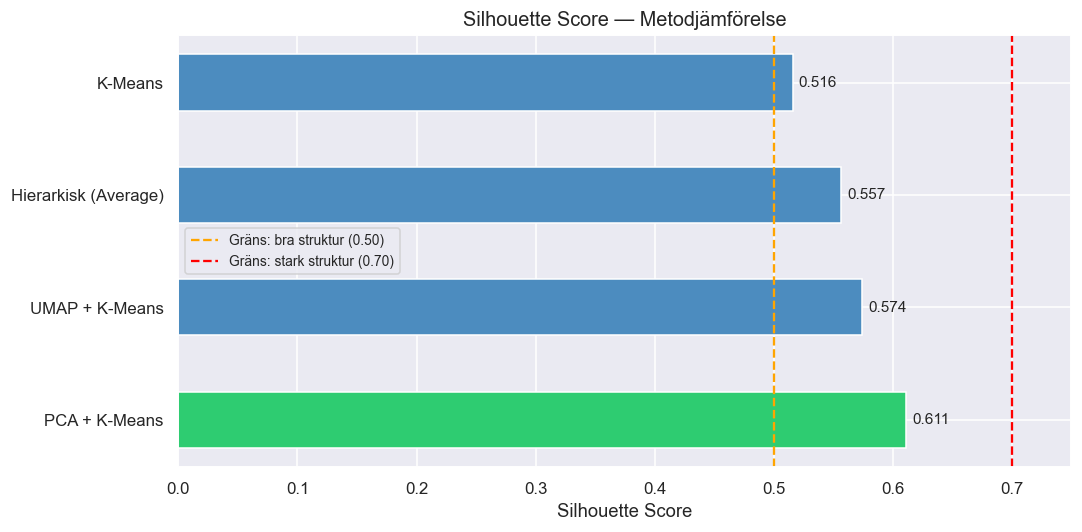

Slutsatser:
  1. PCA + K-Means ger bäst klusterkvalitet för detta dataset
  2. Variansen är linjär (99.6% i 3 PCA-komponenter) — PCA är rätt verktyg
  3. Fyra tydliga marknadsprofile: Japan-only, NA-dominant, Global, EU-dominant
  4. UMAP tillför lite värde när data är linjär — men visar intressant struktur
  5. Hierarkisk klustring bekräftar k=4 utan att k behöver specificeras i förväg


In [ ]:
# ============================================================
# 16. Sammanfattning — Alla metoder jämförda
# ============================================================

summary_data: dict[str, list] = {
    'Metod':      ['K-Means', 'PCA + K-Means', 'UMAP + K-Means', 'Hierarkisk (Average)'],
    'Silhouette': [results[4]['silhouette'], sil_pca, sil_umap_final, sil_scores['average']],
    'Dataset':    ['Full (16,414)', 'Full (16,414)', 'Full (16,414)', 'Sample (500)'],
    'Hastighet':  ['Snabb', 'Snabb', 'Långsam (~2min)', 'Medel']
}

summary_df: pd.DataFrame = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Silhouette', ascending=False).reset_index(drop=True)

print('=== Metodjämförelse ===')
print(summary_df.to_string(index=False))
print()

# Visualisering
fig, ax = plt.subplots(figsize=(10, 5))

colors_bar: list[str] = ['#2ecc71' if s == summary_df['Silhouette'].max()
                          else '#4c8cbf' for s in summary_df['Silhouette']]

bars = ax.barh(
    summary_df['Metod'],
    summary_df['Silhouette'],
    color=colors_bar,
    edgecolor='white',
    height=0.5
)

ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=1.5, label='Gräns: bra struktur (0.50)')
ax.axvline(x=0.7, color='red',    linestyle='--', linewidth=1.5, label='Gräns: stark struktur (0.70)')

for bar, val in zip(bars, summary_df['Silhouette']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Silhouette Score — Metodjämförelse', fontsize=13)
ax.set_xlabel('Silhouette Score')
ax.set_xlim(0, 0.75)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/14_summary.png', bbox_inches='tight', dpi=150)
plt.show()

print('Slutsatser:')
print('  1. PCA + K-Means ger bäst klusterkvalitet för detta dataset')
print('  2. Variansen är linjär (99.6% i 3 PCA-komponenter) — PCA är rätt verktyg')
print('  3. Fyra tydliga marknadsprofile: Japan-only, NA-dominant, Global, EU-dominant')
print('  4. UMAP tillför lite värde när data är linjär — men visar intressant struktur')
print('  5. Hierarkisk klustring bekräftar k=4 utan att k behöver specificeras i förväg')